In [63]:
import numpy as np
import pandas as pd
import statsmodels.api as s
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [86]:
df = pd.read_csv('datasets/indian_houseprice_dataset.csv')
df.head()

,Living Area,Bathrooms,Bedrooms,Lot Size,Age,Fireplace,Price
0,1.982,1.0,3,2.00,133,0,14.2212
1,1.676,1.5,3,0.38,14,1,13.4865
2,1.694,2.0,3,0.96,15,1,11.8007
3,1.800,1.0,2,0.48,49,1,13.8297
4,2.088,1.0,3,1.84,29,1,12.9470


In [87]:
df.shape

(1047, 7)

In [70]:
df.isnull().sum()

Living Area    0
Bathrooms      0
Bedrooms       0
Lot Size       0
Fireplace      0
Price          0
dtype: int64

In [88]:
x = df.drop(columns=['Price'])
y = df['Price']

In [89]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

print(x_train.shape)
print(x_test.shape)

(837, 6)
(210, 6)


In [90]:
x_train = s.add_constant(x_train)
x_test = s.add_constant(x_test)

In [74]:
model = s.OLS(y_train,x_train).fit()

In [75]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     293.5
Date:                Tue, 22 Jul 2025   Prob (F-statistic):          8.81e-181
Time:                        09:52:34   Log-Likelihood:                -2353.2
No. Observations:                 837   AIC:                             4718.
Df Residuals:                     831   BIC:                             4747.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.4704      0.637      2.308      0.021       0.220       2.721
Living Area     6.4666      0.385     16.809      0.000       5.711       7.222
Bathrooms       2.5555      0.322      7.924      0.000       1.923       3.189
Bedrooms       -0.7315      0.249     -2.935      0.003      -1.221      -0.242
Lot Size        0.2490      0.187      1.333      0.183      -0.118       0.616
Fireplace       0.9647      0.330      2.919      0.004       0.316       1.613
==============================================================================
Omnibus:                      128.313   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              577.140
Skew:                           0.627   Prob(JB):                    4.74e-126
Kurtosis:                       6.870   Cond. No.                         21.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [76]:
y_pred = model.predict(x_test)

In [79]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)  
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 18.313989622051164
R-squared: 0.6288896988696748


In [ ]:
df = df.drop(columns=['Age'])

In [53]:
df['Age'].max()

247

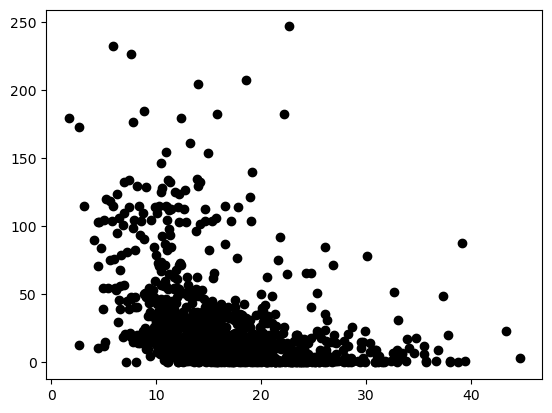

In [ ]:
# Plotting
plt.scatter(df['Price'],df['Age'],c="black")
plt.show()

In [91]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train,y_train)

LinearRegression()

In [92]:
y_pred = lm.predict(x_test)

In [93]:
from sklearn.metrics import r2_score, mean_absolute_error
print(f"r2 score is {r2_score(y_test,y_pred)}")
print(f"mean_absolute_error is {mean_absolute_error(y_test,y_pred)}")

r2 score is 0.6477745304733616
mean_absolute_error is 2.871076400743576


In [94]:
lm.coef_    ### Why there are so many co-efficients???

array([ 0.        ,  6.49599846,  2.00602321, -0.54424387,  0.26517369,
       -0.01851152,  0.84255832])